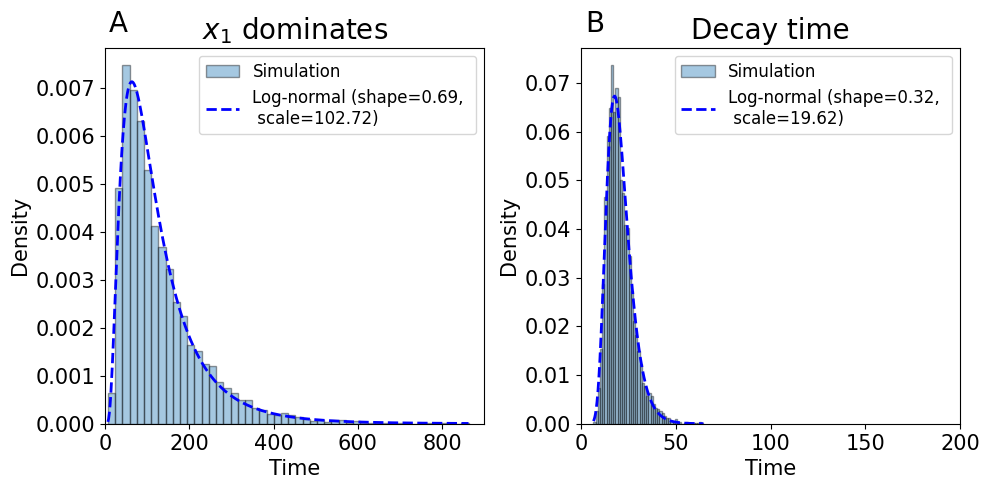

      Dataset       Dist     shape  loc       scale
0      x1_dom  Lognormal  0.691981  0.0  102.718536
1  decay_time  Lognormal  0.317865  0.0   19.615803


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm, gamma

# List to store parameters
results = []

def fit_and_plot(ax, dataset_name, file, filter_cond=None, x_max=None,
                 title="", xlim=None):
    
    df = pd.read_csv(file)
    
    # Apply filter if necessary
    if filter_cond:
        for col, val in filter_cond.items():
            df = df[df[col] == val]
    
    # Trim values if a maximum is specified
    if x_max:
        df = df[df['FinalTime'] < x_max]
    
    data = df['FinalTime'].values
    
    # Lognormal fit (loc=0)
    shape_logn, loc_l, scale_l = lognorm.fit(data, floc=0)
    
    # Store parameters in list
    results.append({
        "Dataset": dataset_name,
        "Dist": "Lognormal",
        "shape": shape_logn,
        "loc": loc_l,
        "scale": scale_l
    })
    
    x = np.linspace(min(data), max(data), 500)
    
    # PDFs
    pdf_lognorm = lognorm.pdf(x, shape_logn, loc_l, scale_l)
    
    # Histogram
    ax.hist(data, bins=50, density=True, alpha=0.4,
            edgecolor='black', label='Simulation')
    ax.plot(x, pdf_lognorm, 'b--', lw=2,
            label=f'Log-normal (shape={shape_logn:.2f}, \n scale={scale_l:.2f})')

    ax.set_xlabel('Time', fontsize=15)
    ax.set_ylabel('Density', fontsize=15)
    ax.set_title(title, fontsize=20)
    ax.legend(fontsize=12)
    ax.tick_params(axis='x', labelsize=15)
    ax.tick_params(axis='y', labelsize=15)
    if xlim:
        ax.set_xlim(xlim)


fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes = axes.flatten()

fit_and_plot(axes[0], "x1_dom", "x1_dom.csv",
             title=r"$x_1$ dominates", xlim=(0, 900))
fit_and_plot(axes[1], "decay_time", "time_ext_x2.csv", x_max=1000,
             title="Decay time", xlim=(0, 200))

# Letters A–I
letters = ['A','B','C','D','E','F','G','H','I']
for i, ax in enumerate(axes):
    ax.text(0.01, 1.1, letters[i], transform=ax.transAxes,
            fontsize=20, va='top')

plt.tight_layout()
plt.show()

# -------------------
# Save parameters
# -------------------
df_parameters = pd.DataFrame(results)
#df_parameters.to_csv("fit_parameters.csv", index=False)
print(df_parameters)

In [2]:
def extract_variable(name):
    if name.startswith("x1"):
        return "x1"
    elif name.startswith("decay"):
        return "decay"

# Create new column
df_parameters["Variable"] = df_parameters["Dataset"].apply(extract_variable)

df_parameters.to_csv("lognormal_parameters.csv", index=False)
df_parameters

,Dataset,Dist,shape,loc,scale,Variable
0,x1_dom,Lognormal,0.691981,0.0,102.718536,x1
1,decay_time,Lognormal,0.317865,0.0,19.615803,decay
